<a href="https://colab.research.google.com/github/RytisBalt/Ma-ininis-mokymasis/blob/PirmasKontrolinis/TMMA_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Duomenų aprašymas:

# Variable	Description
# ID	client loan application id
# year	year of loan application
# loan_limit	indicates whether the loan is conforming (cf) or non-conforming (ncf)
# Gender	gender of the applicant (male, female, joint, sex not available)
# approv_in_adv	indicates whether the loan was approved in advance (pre, nopre)
# loan_type	type of loan (type1, type2, type3)
# loan_purpose	purpose of the loan (p1, p2, p3, p4)
# Credit_Worthiness	credit worthiness (l1, l2)
# open_credit	indicates whether the applicant has any open credit accounts (opc, nopc)
# business_or_commercial	indicates whether the loan is for business/commercial purposes (ob/c - business/commercial, nob/c - personal)
# loan_amount	amount of money being borrowed
# rate_of_interest	interest rate charged on the loan
# Interest_rate_spread	difference between the interest rate on the loan and a benchmark interest rate
# Upfront_charges	initial charges associated with securing the loan
# term	duration of the loan in months
# Neg_ammortization	indicates whether the loan allows for negative ammortization (neg_amm, not_neg)
# interest_only	indicates whether the loan has an interest-only payment option (int_only, not_int)
# lump_sum_payment	indicates if a lump sum payment is required at the end of the loan term (lpsm, not_lpsm)
# property_value	value of the property being financed
# construction_type	type of construction (sb - site built, mh - manufactured home)
# occupancy_type	occupancy type (pr - primary residence, sr- secondary residence, ir - investment property)
# Secured_by	specifies the type of collateral securing the loan (home, land)
# total_units	number of units in the property being financed (1U, 2U, 3U, 4U)
# income	applicant's annual income
# credit_type	applicant's type of credit (CIB - credit information bureau , CRIF - CIRF credit information bureau, EXP - experian , EQUI - equifax)
# Credit_Score	applicant's credit score
# co-applicant_credit_type	co-applicant's type of credit (CIB - credit information bureau EXP - experian)
# age	the age of the applicant.
# submission_of_application	indicates how the application was submitted (to_inst - to institution, not_inst - not to institution)
# LTV	loan-to-value ratio, calculated as the loan amount divided by the property value
# Region	geographic region where the property is located (North, south, central, North-East)
# Security_Type	type of security or collateral backing the loan (direct, indirect)
# Status	indicates whether the loan has been defaulted (1) or not (0)
# dtir1	debt-to-income ratio

data = pd.read_csv('ld.csv')
data.drop(columns = ['ID', 'year','approv_in_adv', 'open_credit',  'interest_only', 'lump_sum_payment', 'Secured_by','total_units','Region', 'Security_Type','loan_limit', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'construction_type', 'credit_type', 'co-applicant_credit_type', 'submission_of_application', 'dtir1'], axis = 1, inplace = True)
data.drop_duplicates(inplace = True)
data.dropna(subset=['term', 'Neg_ammortization', 'age'], inplace=True)
data[['rate_of_interest', 'Interest_rate_spread']].describe()
data['rate_of_interest'].fillna(data['rate_of_interest'].mean(), inplace=True)
data['Interest_rate_spread'].fillna(data['Interest_rate_spread'].mean(), inplace=True)
data['Upfront_charges'].fillna(data['Upfront_charges'].median(), inplace=True)
data['property_value'].fillna(data['property_value'].median(), inplace=True)
median_income_by_age = data.groupby('age')['income'].median()
data['income'] = data['income'].fillna(data['age'].map(median_income_by_age))
data['LTV'].fillna((data['loan_amount']/data['property_value'])*100, inplace = True)
data[['Gender','business_or_commercial', 'Neg_ammortization', 'occupancy_type', 'age']] = data[['Gender','business_or_commercial', 'Neg_ammortization', 'occupancy_type', 'age']].astype('category')
X, y = data.drop('Status', axis=1), data['Status']
X = X.drop('rate_of_interest', axis=1)
X = X.drop('Interest_rate_spread', axis=1)
X = X.drop('Upfront_charges', axis=1)
# Use one-hot encoding to transform categorical features into binary features
X = pd.get_dummies(X)

# Select random 1% of the data due to computational constraints
X = X.sample(frac=0.01, random_state=0)
y = y.loc[X.index]

<ipython-input-25-bbc92315f89b>:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['rate_of_interest'].fillna(data['rate_of_interest'].mean(), inplace=True)
<ipython-input-25-bbc92315f89b>:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

#Random forest

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Padalinome i train ir test data
print(f"Treniruojami: {X_train.shape}, Testuojami: {X_test.shape}")
rf = RandomForestClassifier(random_state=0)

rf.fit(X_train, y_train)

y_pred_a = rf.predict(X_test)
y_pred_a_proba = rf.predict_proba(X_test)[:, 1]

Treniruojami: (1038, 24), Testuojami: (445, 24)


In [ ]:
#Decision tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.model_selection import StratifiedKFold

param_grid = {'max_depth': [1, 2, 3, 4],
        'min_samples_leaf': [2, 3, 5],
        'criterion': ['gini','entropy']}

#Mes juos pasirenkam dėl to, kad noriu kontroliuoti medžio gylį, todėl max_depth yra
#Min_samples_leaf dėl to, kad nustatytume kiek mažiausiai lapų ,,leaf" norime turėti
#Ir criterion dėl kokybės

#Tikimės, kad šitie parametrai mums padės pagerinti modelį, nes dar remiamasi auc kreive, modelis jautresnis
#ir šitie hiperparametrai mum padės


scorer = make_scorer(roc_auc_score, greater_is_better=True)

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,
                           scoring=scorer, cv=3)
grid_search.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid_search.best_params_}")


best_model = grid_search.best_estimator_
y_pred_r = best_model.predict(X_test)
y_pred_r_proba = best_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_r_proba)
print(f"Test AUC Score: {auc_score:.2f}")

Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2}
Test AUC Score: 0.78


In [ ]:
from sklearn.ensemble import BaggingClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)


bagging = BaggingClassifier(estimator=knn, n_estimators=100,
                                       random_state=0)

bagging.fit(X_train, y_train)


y_pred_b = bagging.predict(X_test)
y_pred_b_proba = bagging.predict_proba(X_test)[:, 1]

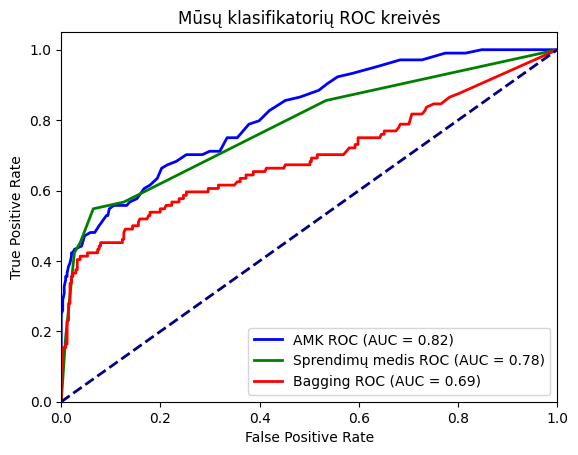

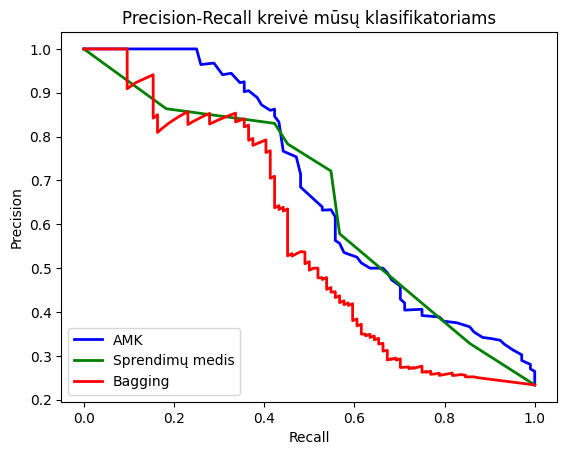

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

fpr_a, tpr_a, _ = roc_curve(y_test, y_pred_a_proba)
roc_auc_a = auc(fpr_a, tpr_a)

fpr_r, tpr_r, _ = roc_curve(y_test, y_pred_r_proba)
roc_auc_r = auc(fpr_r, tpr_r)

fpr_b, tpr_b, _ = roc_curve(y_test, y_pred_b_proba)
roc_auc_b = auc(fpr_b, tpr_b)

plt.figure()
plt.plot(fpr_a, tpr_a, color='blue', lw=2, label=f'AMK ROC (AUC = {roc_auc_a:.2f})')
plt.plot(fpr_r, tpr_r, color='green', lw=2, label=f'Sprendimų medis ROC (AUC = {roc_auc_r:.2f})')
plt.plot(fpr_b, tpr_b, color='red', lw=2, label=f'Bagging ROC (AUC = {roc_auc_b:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Mūsų klasifikatorių ROC kreivės')
plt.legend(loc="lower right")
plt.show()

precision_a, recall_a, _ = precision_recall_curve(y_test, y_pred_a_proba)
precision_r, recall_r, _ = precision_recall_curve(y_test, y_pred_r_proba)
precision_b, recall_b, _ = precision_recall_curve(y_test, y_pred_b_proba)

plt.figure()
plt.plot(recall_a, precision_a, color='blue', lw=2, label='AMK')
plt.plot(recall_r, precision_r, color='green', lw=2, label='Sprendimų medis')
plt.plot(recall_b, precision_b, color='red', lw=2, label='Bagging')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall kreivė mūsų klasifikatoriams')
plt.legend(loc="lower left")
plt.show()


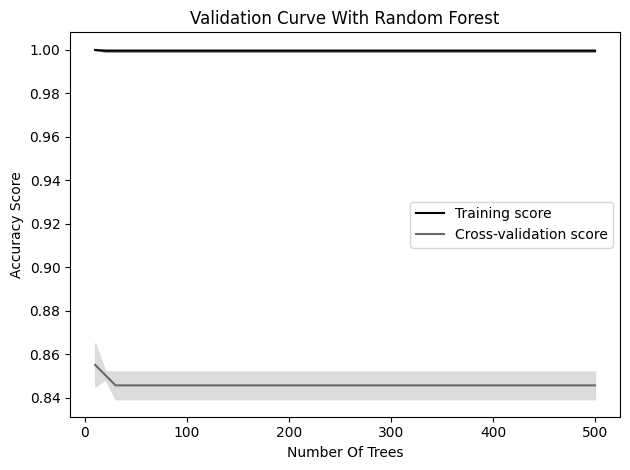

In [ ]:
from sklearn.model_selection import validation_curve

param_range = np.arange(10, 510, 10)

train_scores, test_scores = validation_curve(
    rf, X, y, param_name="max_features", param_range=param_range, scoring="accuracy", n_jobs=-1)


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

import matplotlib.pyplot as plt
plt.plot(param_range, train_mean, label="Training score", color="black")
plt.plot(param_range, test_mean, label="Cross-validation score", color="dimgrey")

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, color="gray")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, color="gainsboro")

plt.title("Validation Curve With Random Forest")
plt.xlabel("Number Of Trees")
plt.ylabel("Accuracy Score")
plt.tight_layout()
plt.legend(loc="best")
plt.show()

Medžio A (max depth=4) mazgai: 17
Medžio B (min Gini decrease=0.01) mazgai: 9
Medžio C (max leaf nodes=5) mazgai: 9


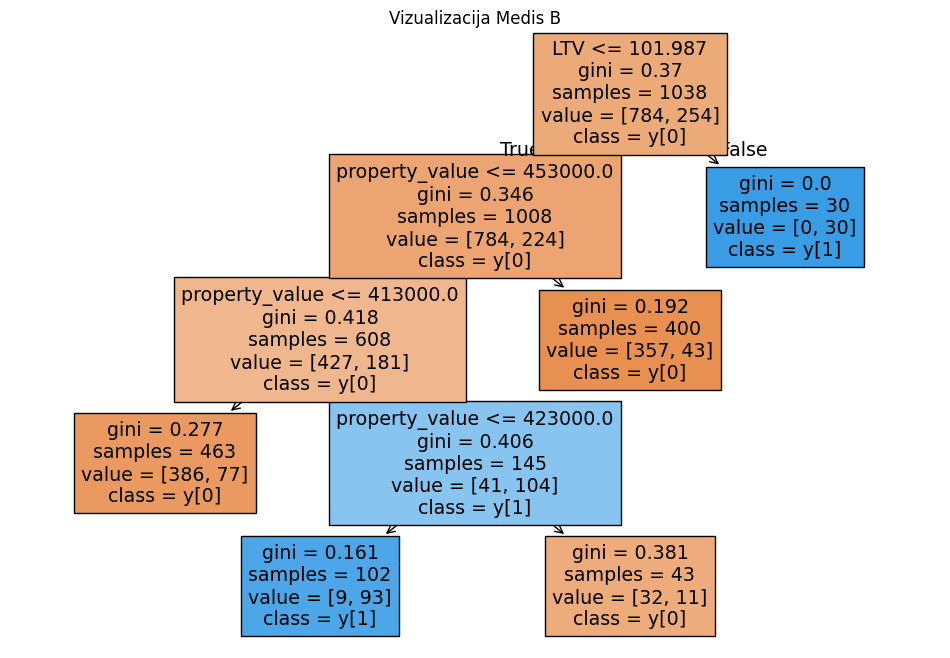

Svarbiausias požymis: property_value


In [ ]:
#3 uzduotis konstruojame medžius
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_a = DecisionTreeClassifier(max_depth=4, random_state=0)
tree_a.fit(X_train, y_train)


tree_b = DecisionTreeClassifier(min_impurity_decrease=0.01, random_state=0)
tree_b.fit(X_train, y_train)


tree_c = DecisionTreeClassifier(max_leaf_nodes=5, random_state=0)
tree_c.fit(X_train, y_train)

nodes_a = tree_a.tree_.node_count
nodes_b = tree_b.tree_.node_count
nodes_c = tree_c.tree_.node_count

print(f"Medžio A (max depth=4) mazgai: {nodes_a}")
print(f"Medžio B (min Gini decrease=0.01) mazgai: {nodes_b}")
print(f"Medžio C (max leaf nodes=5) mazgai: {nodes_c}")

min_nodes = min(nodes_a, nodes_b, nodes_c)
if min_nodes == nodes_a:
    chosen_tree = tree_a
    tree_name = 'Medis A'
elif min_nodes == nodes_b:
    chosen_tree = tree_b
    tree_name = 'Medis B'
else:
    chosen_tree = tree_c
    tree_name = 'Medis C'

plt.figure(figsize=(12, 8))
plot_tree(chosen_tree, filled=True, feature_names=X.columns, class_names=True)
plt.title(f"Vizualizacija {tree_name}")
plt.show()

#Surasime geriausią požymį
importance = chosen_tree.feature_importances_
most_important_feature_index = np.argmax(importance)
most_important_feature = X.columns[most_important_feature_index]

print(f"Svarbiausias požymis: {most_important_feature}")

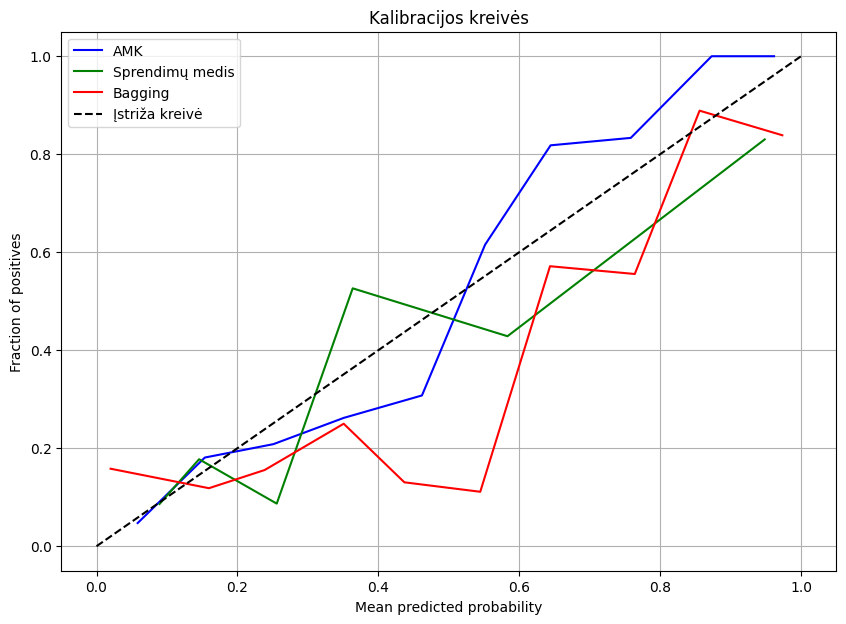

In [ ]:
from sklearn.calibration import calibration_curve

prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_pred_a_proba, n_bins=10)
prob_true_dt, prob_pred_dt = calibration_curve(y_test, y_pred_r_proba, n_bins=10)
prob_true_bagging, prob_pred_bagging = calibration_curve(y_test, y_pred_b_proba, n_bins=10)


plt.figure(figsize=(10, 7))


plt.plot(prob_pred_rf, prob_true_rf, label='AMK', color='blue')

plt.plot(prob_pred_dt, prob_true_dt,  label='Sprendimų medis', color='green')

plt.plot(prob_pred_bagging, prob_true_bagging, label='Bagging', color='red')

plt.plot([0, 1], [0, 1], linestyle='--', label='Įstriža kreivė', color='black')

# Add labels and title
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Kalibracijos kreivės')
plt.legend(loc='best')
plt.grid(True)
plt.show()

#Nubrežtos tris kalibracijos kreivės, pagal idėja, kuri eina įstrižai į viršų ta
#yra geriausia, mūsų atveju sprendžiant iš akies tai yra mėlyna AMK kreivė, nes
#ji kaip ir eina labiausiai įstrižai į viršų